# Salary Prediction Using Linear Regression

In this project, we will predict an employee's salary based on
their years of experience.

### Input
Years of Experience

### Output
Salary

We will use Simple Linear Regression.

Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
import pandas as pd

data = {
    "YearsExperience": [
        1, 1, 2, 2, 3, 3,
        4, 4, 4, 4,
        5, 5, 6, 6,
        7, 7, 8, 8,
        9, 10, 10, 11,
        12, 12, 13, 14,
        15, 16, 18, 20
    ],

    "Salary": [
        28000, 32000,
        34000, 38000,
        36000, 42000,

        40000, 45000, 48000, 52000,

        46000, 55000,
        50000, 60000,
        57000, 65000,
        62000, 72000,
        68000,
        70000, 78000,
        75000,
        82000, 88000,
        85000,
        92000,
        98000,
        102000,
        110000,
        118000
    ]
}

df = pd.DataFrame(data)

df

,YearsExperience,Salary
0,1,28000
1,1,32000
2,2,34000
3,2,38000
4,3,36000
5,3,42000
6,4,40000
7,4,45000
8,4,48000
9,4,52000


In [3]:
df.shape

(30, 2)

In [4]:
df.describe()


,YearsExperience,Salary
count,30.000000,30.000000
mean,8.000000,64266.666667
std,5.186189,24466.632215
min,1.000000,28000.000000
25%,4.000000,45250.000000
50%,7.000000,61000.000000
75%,11.750000,81000.000000
max,20.000000,118000.000000


In [5]:
df.sample(5)

,YearsExperience,Salary
17,8,72000
18,9,68000
10,5,46000
4,3,36000
21,11,75000


understand the data

Visualize the Relationship

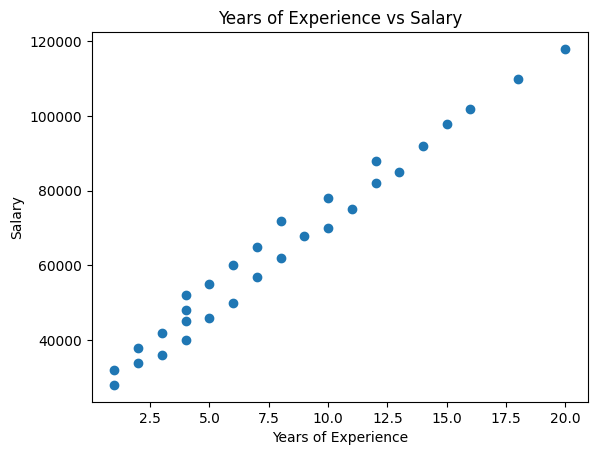

In [6]:
plt.scatter(
    df["YearsExperience"],
    df["Salary"]
)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Years of Experience vs Salary")

plt.show()

seprate dependent and independent variable

In [7]:
X = df[["YearsExperience"]]

y = df["Salary"]

Split the Dataset

We usually do not train the model using all available data.

We divide the data into:

80% → Training Data
20% → Testing Data

In [8]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 )

Create the Linear Regression Model

In [9]:
model = LinearRegression()

In [10]:
model.fit(X_train, y_train)

LinearRegression()

check learned coefficient

In [11]:
model.coef_

array([4682.73017064])

In [13]:
model.intercept_

np.float64(25665.166572910814)

In [14]:
y_pred = model.predict(X_test)

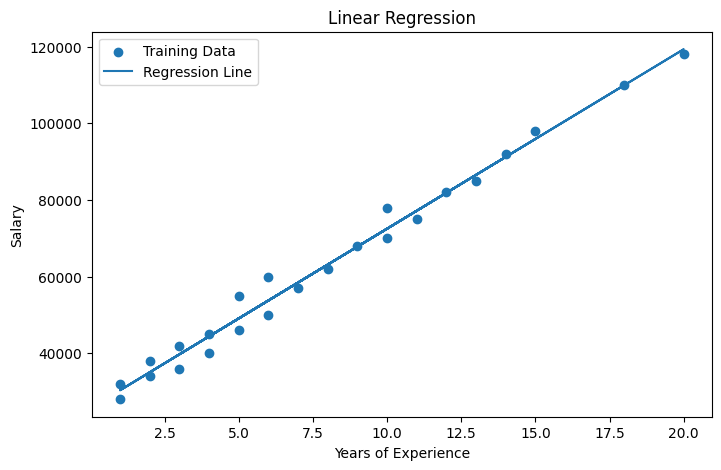

In [15]:
# Visualize the Regression Line
plt.figure(figsize=(8, 5))

plt.scatter(
    X_train,
    y_train,
    label="Training Data"
)

plt.plot(
    X_train,
    model.predict(X_train),
    label="Regression Line"
)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression")

plt.legend()

plt.show()

Predict Salary for a New Employee

In [17]:
new_employee = pd.DataFrame({ "YearsExperience": [8] })
model.predict(new_employee)

array([63127.007938])

In [20]:
predicted_salary = model.predict(new_employee)
predicted_salary

array([63127.007938])

Predict for Multiple Experience Values

In [18]:

new_data = pd.DataFrame({
    "YearsExperience": [2, 4, 6, 8, 10, 12, 15]
})

predictions = model.predict(new_data)

new_data["PredictedSalary"] = predictions

new_data

,YearsExperience,PredictedSalary
0,2,35030.626914
1,4,44396.087255
2,6,53761.547597
3,8,63127.007938
4,10,72492.468279
5,12,81857.928621
6,15,95906.119132


In [21]:
import joblib

joblib.dump(model, "linear_regression_model.pkl")

['linear_regression_model.pkl']

In [22]:
loaded_model = joblib.load("linear_regression_model.pkl")